# Applied Machine Learning

## Assignment7 - ShunFai Lee

In [ ]:
#import all needed libraries
from sklearn.model_selection import train_test_split,StratifiedKFold,cross_val_score,GridSearchCV,cross_validate,KFold
from sklearn.metrics import confusion_matrix, make_scorer, recall_score, precision_score, accuracy_score,r2_score, adjusted_rand_score
from sklearn.metrics.cluster import contingency_matrix
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn import tree
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.base import BaseEstimator, TransformerMixin

#### Check and sanitization of dataset

In [3]:
#load data set
df_train_raw = pd.read_csv("clustering_synthetic_dataset.csv")
print("synthetic_dataset:")
print(df_train_raw.dtypes,"\n")
print(f'total rows_N={len(df_train_raw)}, features_M={len(df_train_raw.columns)}\n')


df_train_raw.head()



synthetic_dataset:
f1    float64
f2    float64
dtype: object 

total rows_N=750, features_M=2



,f1,f2
0,0.494261,1.451067
1,-1.428081,-0.837064
2,0.338559,1.038759
3,0.119001,-1.053976
4,1.122425,1.774937


### Question1:
####  Plot the data with a scatterplot

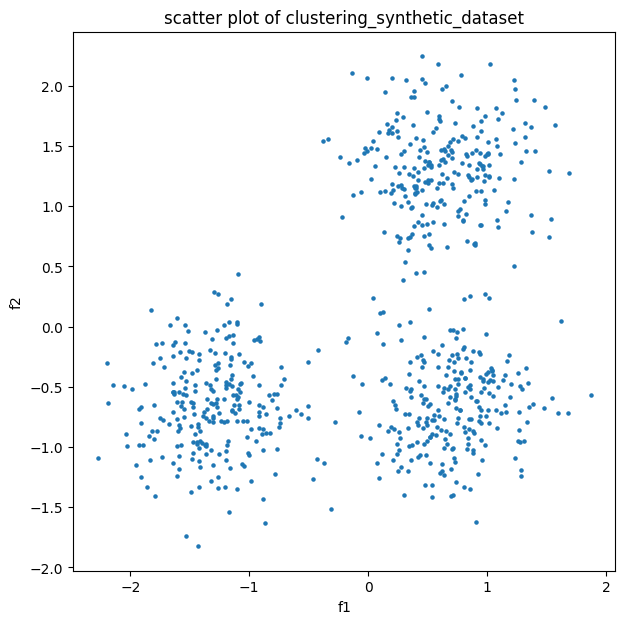

In [8]:
fig, axs = plt.subplots(1, figsize=(7, 7))
axs.scatter(df_train_raw[df_train_raw.columns[0]],df_train_raw[df_train_raw.columns[1]],s=5)
axs.set_xlabel(df_train_raw.columns[0])
axs.set_ylabel(df_train_raw.columns[1])
axs.set_title("scatter plot of clustering_synthetic_dataset")
plt.show()

### Question1:

From the above scatter plot, it is highly likely that there are 3 species in the data, with 3 very distinctly identifiable clusters.

In [ ]:
#range of values of the two features
value_ranges = {c:{'min':df_train_raw.min()[c],'max':df_train_raw.max()[c]} for c in df_train_raw.columns}
value_ranges

{'f1': {'min': np.float64(-2.27447426719), 'max': np.float64(1.87043802694)},
 'f2': {'min': np.float64(-1.82380067733), 'max': np.float64(2.2457941917)}}

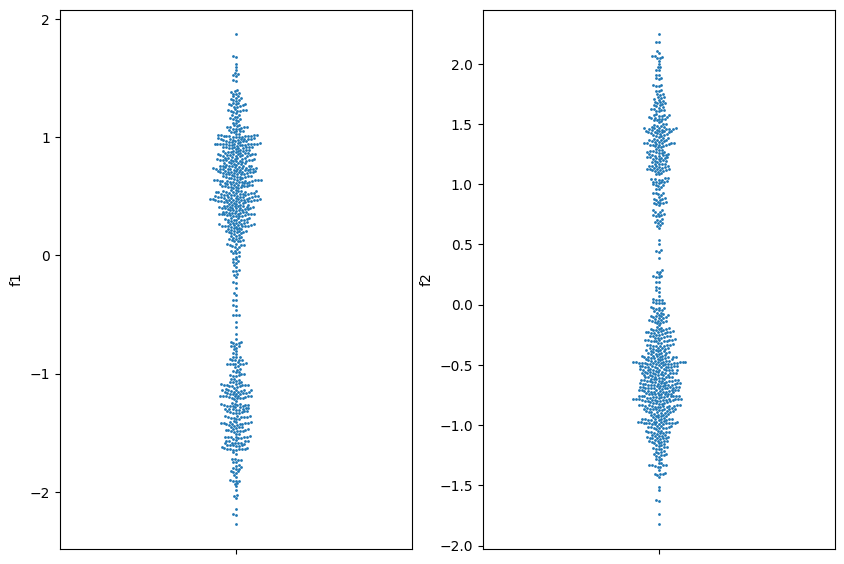

In [22]:
import seaborn as sns
_, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 7))
# Plot each feature of their own
sns.swarmplot(ax=ax[0], y=df_train_raw["f1"], size=2)
sns.swarmplot(ax=ax[1], y=df_train_raw["f2"], size=2)
plt.show()


### Question2:
#### rough feature ranges

From the above data plot and the range of values of the two features, f1 has an overall range of [-2.27, 1.87], and the date are in two clusters, with the separation at -0.5 approximately, so there are two sub range between [-2.27,-0.5] and [-0.5,1.87].<br>
Similarly, f2 has an overall range of [-1.82, 2.25], and the date are in two clusters as well, with the separation at 0.5 approximately, so there are two sub range between [-1.82,0.5] and [0.5,2.25].<br>

If we cross reference to the scatter plot in Question 1, we can conclude that: 
- species 1 has feature f1 in the range of [-2.27,-0.5] and f2 in the range of [-1.82,0.5].
- species 2 has feature f1 in the range of [-0.5,1.87] and f2 in the range of [-1.82,0.5].
- species 3 has feature f1 in the range of [-0.5,1.87] and f2 in the range of [0.5,2.25].


### Question3:
#### Use K-means clustering to find anomalies

In [ ]:
#number of clusters
k=3
#set the model
km = KMeans(n_clusters=k, init='random', n_init=10, max_iter=300, random_state=0)
km.fit_predict(df_train_raw)
centroids = km.cluster_centers_
y_pred = km.labels_
print(f'centroids:')
for i, [x,y] in enumerate(centroids):
    print(f'cluster {i} f1,f2 :[{x:.3f},{y:.3f}]')

centroids:
cluster 0 f1,f2 :[0.623,1.317]
cluster 1 f1,f2 :[0.695,-0.644]
cluster 2 f1,f2 :[-1.303,-0.657]


After fitting the kmeans model, plot the each cluster and its centroid for a visual check.

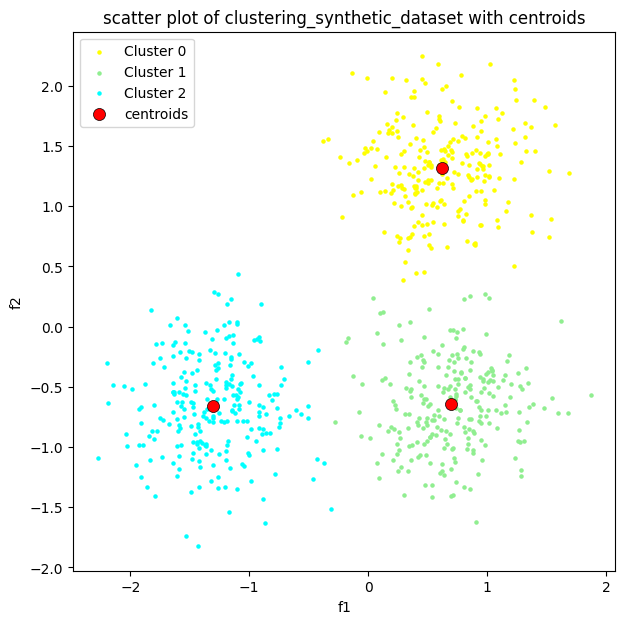

In [190]:
#plot the scatter again with centroids and cluster from k-means
fig, axs2 = plt.subplots(1, figsize=(7, 7))
normal_color = ['yellow', 'lightgreen', 'cyan']

for i in np.unique(y_pred):
    cluster_ID = (y_pred==i)
    axs2.scatter(df_train_raw.loc[cluster_ID,df_train_raw.columns[0]],df_train_raw.loc[cluster_ID,df_train_raw.columns[1]],label=f'Cluster {i}',s=5,color=normal_color[i])
axs2.set_xlabel(df_train_raw.columns[0])
axs2.set_ylabel(df_train_raw.columns[1])
axs2.set_title("scatter plot of clustering_synthetic_dataset with centroids")
#annotate the centroids
axs2.scatter(centroids[:,0], centroids[:,1], c='red', marker='o', 
    s=75, edgecolor='black', linewidth=0.5,
    label=f'centroids',
    zorder=4
)
axs2.legend()
plt.show()

From the above scatter plot with centroids, it appears that each cluster is in circular shape, and density increas towards the centroids. It indicates that each cluster might follows a normal distribution.

Because kmeans does not have implicit definition for anomalies, a strategy need to be defined for identifying them. An general approach would be to calculate the euclidean distance between each point of each cluster and the centroids. Then the intra-cluster distance (as mean) and the standard deviation can be computed.

Anomalies can then be explicitly defined as being some points that are more than 2 standard deviation away from mean. And in general, that will results in about 5% of all points being treated as anomalies, and all of them would be at around boundaries.

Number of anomalies: 32
Number of normal   :718


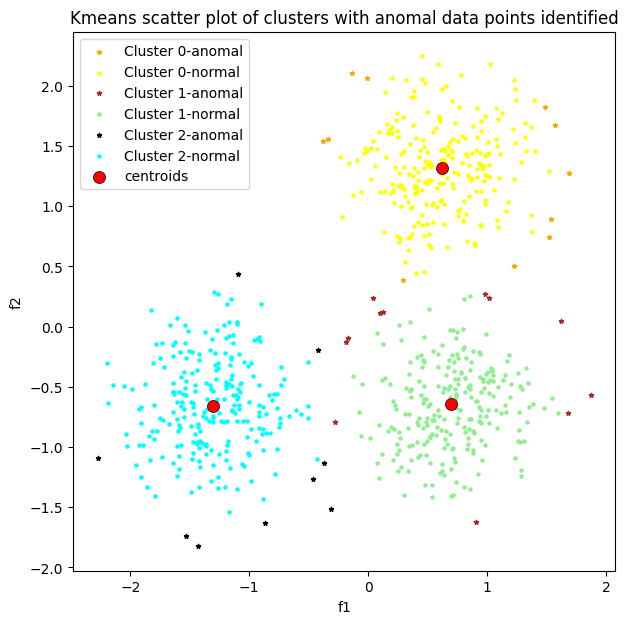

In [202]:
#calculate intra-cluster distance for each cluster
centers = centroids[y_pred]
distance = np.sqrt((df_train_raw['f1']-centers[:,0])**2+(df_train_raw['f2']-centers[:,1])**2)
#find the mean and standard deviation for each cluster
mean = np.array([np.mean(distance[y_pred==i]) for i in range(len(centroids))])
std = np.array([np.std(distance[y_pred==i]) for i in range(len(centroids))])
#separate each cluster into anomal and normal points
anomal = df_train_raw.iloc[(distance>mean[y_pred]+2*std[y_pred])==True]
y_pred_anomal = y_pred[anomal.index]
normal = df_train_raw.drop(anomal.index,axis=0)
y_pred_normal = y_pred[normal.index]

print(f'Number of anomalies: {len(anomal)}')
print(f'Number of normal   :{len(normal)}')


#plot the scatter again with centroids, normal and anomalies under the kmeans
fig, axs3 = plt.subplots(1, figsize=(7, 7))
#color each cluster with distinct color
normal_color = ['yellow', 'lightgreen', 'cyan']
anomal_color = ['orange', 'brown', 'black']

#plot the scatter
for i in np.unique(y_pred):
    cluster_ID_normal = (y_pred_normal==i)
    cluster_ID_anomal = (y_pred_anomal==i)
    axs3.scatter(anomal.loc[cluster_ID_anomal,anomal.columns[0]],anomal.loc[cluster_ID_anomal,anomal.columns[1]],label=f'Cluster {i}-anomal',marker='*',s=10,color=anomal_color[i])
    axs3.scatter(normal.loc[cluster_ID_normal,normal.columns[0]],normal.loc[cluster_ID_normal,normal.columns[1]],label=f'Cluster {i}-normal',s=5,color=normal_color[i])

axs3.set_xlabel(df_train_raw.columns[0])
axs3.set_ylabel(df_train_raw.columns[1])
axs3.set_title("Kmeans scatter plot of clusters with anomal data points identified")
#annotate the centroids
axs3.scatter(centroids[:,0], centroids[:,1], c='red', marker='o', 
    s=75, edgecolor='black', linewidth=0.5,
    label=f'centroids',
    zorder=4
)
axs3.legend()
plt.show()


### Question3:

The above scatter plot illustrate each cluster, and the identified anomalies for each of them. 32 anomalies, out of 750 total points, among all clusters are identified, which account for about 4.2% of the data. In general, this percentage matches with the prediction that about 5% of the points would be classified as anomalies by choosing mean+2*standard deviation as the cutoff.

### Question4:
#### Use DBSCAN clustering to find anomalies

Number of anomalies: 40
Number of normal   :710
get in


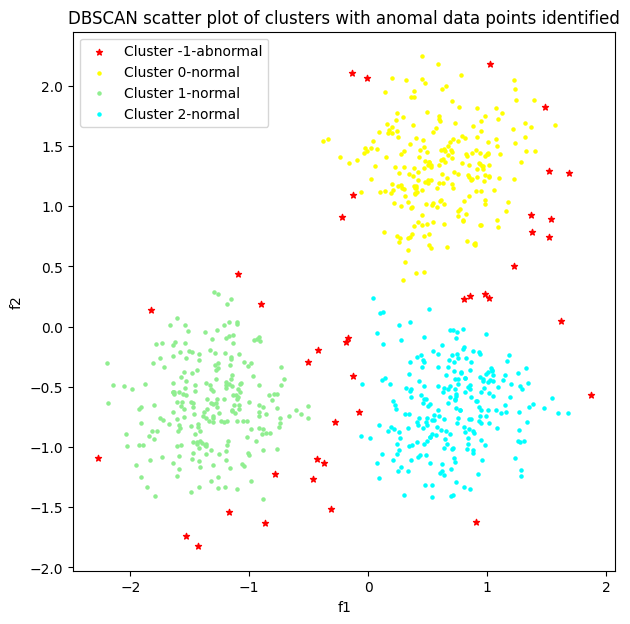

In [241]:
#use DBSCAN with eps=0.2
epsilon = 0.2
db = DBSCAN(eps=epsilon)
db_y_pred = db.fit_predict(df_train_raw)

#count each clusters and the anomalies
cluster_counts = {str(i):len(db_y_pred[db_y_pred==i]) for i in np.unique(db_y_pred)}
print(f'Number of anomalies: {cluster_counts['-1']}')
print(f'Number of normal   :{np.sum([cluster_counts[i] for i in cluster_counts if i!='-1'])}')

#plot the scatter again with centroids, normal and anomalies under the kmeans
fig, axs4 = plt.subplots(1, figsize=(7, 7))
#color each cluster with distinct color
normal_color = ['yellow', 'lightgreen', 'cyan']
anomal_color = ['red']

#plot the scatter
for i in np.unique(db_y_pred):
    if str(i)!='-1':
        axs4.scatter(df_train_raw.loc[(db_y_pred==i),df_train_raw.columns[0]],df_train_raw.loc[(db_y_pred==i),df_train_raw.columns[1]],label=f'Cluster {i}-normal',s=5,color=normal_color[i])
    else:
        print('get in')
        axs4.scatter(df_train_raw.loc[(db_y_pred==i),df_train_raw.columns[0]],df_train_raw.loc[(db_y_pred==i),df_train_raw.columns[1]],label=f'Cluster {i}-abnormal',marker='*',s=20,color='red')

axs4.set_xlabel(df_train_raw.columns[0])
axs4.set_ylabel(df_train_raw.columns[1])
axs4.set_title("DBSCAN scatter plot of clusters with anomal data points identified")

axs4.legend()
plt.show()

### Question4:

By choosing epsilon = 0.2, the DBSCAN clustering identifies 40 points as noise. The results is plotted on the above scatter plot with each clusters in different color and the noise points in bright red. By visually checking the plot, all noise points are far from cluster centers and are in low density area. In general, it is an acceptable result.

### Question5:

#### Use decision Tree to classify species

Choosing the results from Question 3 with Kmeans

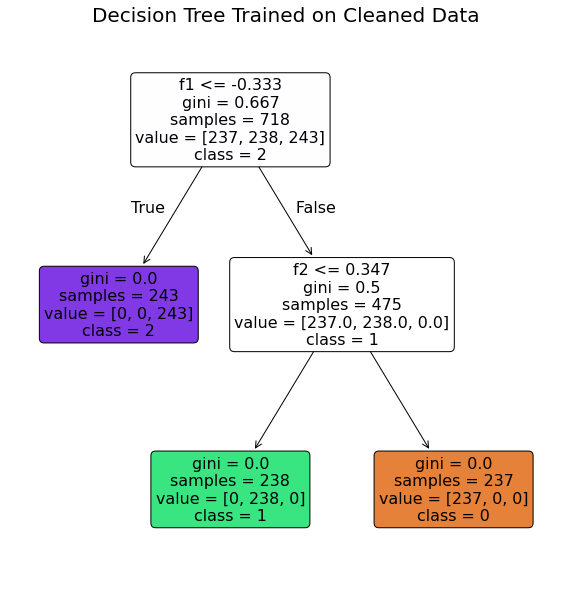

In [259]:
#grab the filtered points from Question 3
X_filtered = normal
#use the cluster ID found in as the Y
Y_filtered = y_pred_normal
Dtree = tree.DecisionTreeClassifier(random_state=0)
model = Dtree.fit(X_filtered,Y_filtered)

plt.rcParams['figure.dpi'] = 72
fig, axs5  = plt.subplots(1, figsize=(10, 10))
tree.plot_tree(Dtree, feature_names=X_filtered.columns, class_names=[str(i) for i in np.unique(Y_filtered)],
               filled=True, rounded=True, ax=axs5)
plt.title("Decision Tree Trained on Cleaned Data",size=20)
plt.show()